# 01 — Regression: Predicting Expected Loss on Defaulted Loans

**How to use this notebook:** run each cell in order (Shift+Enter). Read the
text above each code cell first, then read the comments *inside* the code.
Everything is self-contained — no other files needed, so it runs in Anaconda,
Jupyter, Colab, or VS Code.

## The problem in plain words
When a borrower **defaults** (stops paying), the bank rarely loses the whole
loan — it recovers some money. The amount it *fails* to recover is the **loss**.
Predicting that dollar loss is a **regression** problem (the answer is a number).

This is the **"L" in the PD / LGD / EAD** credit-risk framework:
- **PD** – Probability of Default (a *classification* problem — module 02)
- **LGD** – Loss Given Default, the % of the loan lost (regression)
- **EAD** – Exposure At Default, the amount owed when default happens

Expected Loss ≈ **PD × LGD × EAD**. Here we model the loss in dollars directly.

## Setup: import the tools we need

In [1]:
# numpy = fast maths on arrays of numbers
import numpy as np
# pandas = tables (rows and columns), like Excel inside Python
import pandas as pd
# matplotlib = drawing charts. The "inline" magic shows charts inside the notebook.
import matplotlib.pyplot as plt
%matplotlib inline
# scipy.stats = statistics helpers (we use it for the normality / QQ plot)
from scipy import stats
# scikit-learn = the standard machine-learning library
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler

# A fixed "seed" makes the random numbers come out the SAME every run.
# Reproducibility matters for learning and for model risk reviews.
SEED = 42
print("Libraries loaded.")

Libraries loaded.


## Step 1 — Create the data

In a real bank you would load this from a database. To keep things runnable
anywhere, we **generate** realistic fake defaulted loans from a formula we
choose ourselves. Because we know the true formula, we can later check whether
the model recovers it.

The key trick: a defaulted loan loses a *fraction* of its value — the **LGD
rate** between 0% and 100%. We build that rate from the risk factors, then
multiply by the loan amount to get dollars. This guarantees loss < loan amount
and lets every feature matter.

In [2]:
def make_dataset(n=6000, seed=SEED):
    # Create a random-number generator with our fixed seed.
    rng = np.random.default_rng(seed)

    # --- generate each input feature with a believable distribution ---
    # Loan amounts are right-skewed (many small, few huge) -> lognormal fits.
    loan_amount = np.round(rng.lognormal(10.0, 0.5, n), 2)
    # Collateral is a noisy multiple of the loan (the asset backing it).
    collateral_value = np.round(loan_amount * rng.uniform(0.4, 1.3, n), 2)
    # Income, also right-skewed, generated on its own.
    annual_income = np.round(rng.lognormal(11.0, 0.4, n), 2)
    # Debt-to-income: most people sit between ~0.1 and ~0.6.
    debt_to_income = np.round(np.clip(rng.normal(0.35, 0.12, n), 0.02, 0.9), 3)
    # Interest rate %: riskier borrowers pay more, so it tracks debt_to_income.
    interest_rate = np.round(np.clip(3 + 18*debt_to_income + rng.normal(0, 2, n), 2, 30), 2)
    # Loan term: pick from common loan lengths (in months).
    loan_term_months = rng.choice([12, 24, 36, 48, 60, 72], size=n)
    # Borrower age: roughly normal around 40, kept sensible.
    borrower_age = np.clip(rng.normal(40, 12, n), 19, 80).astype(int)
    # Prior defaults: most have 0, a few more (Poisson is good for counts).
    num_prior_defaults = rng.poisson(0.3, n)
    # Region: a text label; recovery efficiency differs by region.
    region = rng.choice(["East","West","Central","North"], n, p=[.35,.30,.20,.15])
    # monthly_payment is loan spread over the term + interest. We ADD it on
    # purpose so it correlates with loan_amount -> teaches multicollinearity later.
    monthly_payment = np.round(loan_amount*(1+interest_rate/100)/loan_term_months, 2)

    # --- build the TARGET from a known formula + noise ---
    # coverage = how much of the loan the collateral covers. More -> less loss.
    coverage = collateral_value / loan_amount
    # Build the LGD rate on a "logit" scale (any number); each line is a cause.
    lgd_logit = (0.4
                 - 1.6*coverage              # more collateral -> less loss
                 + 1.8*debt_to_income        # more debt burden -> more loss
                 + 0.05*interest_rate        # riskier loans -> more loss
                 + 0.45*num_prior_defaults   # repeat defaulters -> more loss
                 + rng.normal(0, 0.4, n))    # noise = what we can't explain
    # Region shifts the loss rate up/down a little.
    lgd_logit += pd.Series(region).map({"East":0,"West":.20,"Central":-.10,"North":.30}).to_numpy()
    # sigmoid squashes the logit into a rate between 0 and 1.
    lgd_rate = 1.0/(1.0+np.exp(-lgd_logit))
    # Dollars lost = rate x amount. Floor at $1 so log() is always defined later.
    loss_amount = np.maximum(np.round(lgd_rate*loan_amount, 2), 1.0)

    # --- pack everything into one tidy table ---
    return pd.DataFrame({
        "loan_amount":loan_amount, "collateral_value":collateral_value,
        "annual_income":annual_income, "debt_to_income":debt_to_income,
        "interest_rate":interest_rate, "loan_term_months":loan_term_months,
        "borrower_age":borrower_age, "num_prior_defaults":num_prior_defaults,
        "monthly_payment":monthly_payment, "region":region,
        "loss_amount":loss_amount})

# Build the table and look at it.
df = make_dataset()
print(f"Rows: {len(df):,}  Columns: {df.shape[1]}")
df.head()

Rows: 6,000  Columns: 11


,loan_amount,collateral_value,annual_income,debt_to_income,interest_rate,loan_term_months,borrower_age,num_prior_defaults,monthly_payment,region,loss_amount
0,25651.53,25270.52,85575.90,0.573,12.18,72,55,0,399.67,Central,14879.85
1,13095.29,14352.05,76292.07,0.190,7.55,12,48,1,1173.67,East,4982.88
2,32055.55,22237.65,55227.73,0.438,12.49,72,34,0,500.82,Central,17252.82
3,35252.17,43239.65,90486.61,0.466,12.03,48,48,1,822.77,East,21290.48
4,8303.92,8801.19,53260.37,0.412,10.16,48,30,0,190.57,Central,4584.41


In [3]:
# A quick statistical summary of the target we want to predict.
df["loss_amount"].describe().round(2)

count     6000.00
mean     14409.32
std       8819.55
min        971.78
25%       8306.54
50%      12412.02
75%      18136.27
max      78563.16
Name: loss_amount, dtype: float64

### Why we will model the *log* of the loss

The loss is heavily **right-skewed** (lots of small losses, a few huge ones).
Linear regression works best when the target is roughly symmetric. Taking the
**logarithm** squashes the long tail into a nice bell-ish shape. We will predict
`log(loss)`, then exponentiate predictions back to dollars to report them.

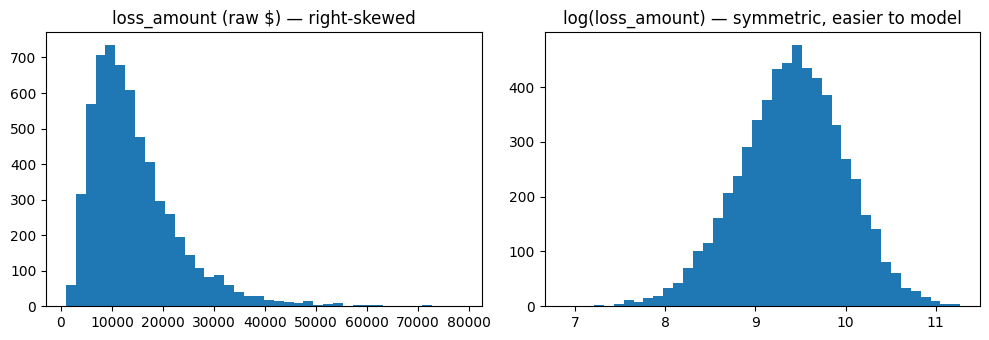

In [4]:
# Draw the loss before and after a log transform to SEE the skew disappear.
fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
ax[0].hist(df["loss_amount"], bins=40)                 # raw dollars: long right tail
ax[0].set_title("loss_amount (raw $) — right-skewed")
ax[1].hist(np.log(df["loss_amount"]), bins=40)         # logged: much more symmetric
ax[1].set_title("log(loss_amount) — symmetric, easier to model")
plt.tight_layout(); plt.show()

## Step 2 — Linear regression *from scratch*

Before using scikit-learn, let's build the model ourselves so we understand it.
Being able to do this is a classic interview question.

**The model in one sentence:** predict the target as a weighted sum of features:
$$\hat{y} = w_0 + w_1 x_1 + w_2 x_2 + \dots$$
"Training" = finding the weights that make predictions closest to reality,
measured by **Mean Squared Error** (the average squared mistake). Two ways:

1. **Normal Equation** — an exact one-shot formula: $w = (X^\top X)^{-1} X^\top y$.
2. **Gradient Descent** — start at zero, repeatedly step *downhill* on the error.
   This is the engine behind almost all modern machine learning.

In [5]:
class LinearRegressionScratch:
    # Our own linear regression, mirroring scikit-learn's fit/predict style.
    def __init__(self, method="normal", learning_rate=0.01, n_iterations=5000):
        self.method = method                  # "normal" or "gradient"
        self.learning_rate = learning_rate    # step size for gradient descent
        self.n_iterations = n_iterations      # how many improvement steps
        self.weights = None                   # the slopes (filled in by fit)
        self.bias = None                      # the intercept (value when all x=0)
        self.cost_history = []                # error at each step (to plot learning)

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)        # make sure inputs are float arrays
        y = np.asarray(y, dtype=float).ravel()
        m, n = X.shape                        # m = rows, n = features
        if self.method == "normal":
            # Add a column of 1s so the intercept is just another weight.
            Xb = np.c_[np.ones(m), X]
            # The exact least-squares solution. pinv works even with correlated cols.
            theta = np.linalg.pinv(Xb.T @ Xb) @ Xb.T @ y
            self.bias, self.weights = theta[0], theta[1:]
        elif self.method == "gradient":
            self.weights = np.zeros(n); self.bias = 0.0   # blank slate
            for _ in range(self.n_iterations):
                y_hat = X @ self.weights + self.bias      # 1) predict
                error = y_hat - y                         # 2) how wrong we are
                self.cost_history.append(np.mean(error**2))  # 3) record MSE
                dw = (2/m) * (X.T @ error)                # 4) gradient for weights
                db = (2/m) * np.sum(error)                #    gradient for bias
                self.weights -= self.learning_rate * dw   # 5) step downhill
                self.bias    -= self.learning_rate * db
        return self

    def predict(self, X):
        X = np.asarray(X, dtype=float)
        return X @ self.weights + self.bias    # weighted sum + intercept
print("LinearRegressionScratch defined.")

LinearRegressionScratch defined.


### Prove it works: recover hidden weights

We invent data with known weights `[4, -2, 1.5]` and bias `7`, then check both
methods find them. Gradient descent needs features on a similar scale, so we use
standardised random data here.

In [6]:
rng = np.random.default_rng(0)
X = rng.normal(size=(500, 3))                       # 500 rows, 3 features
true_w = np.array([4.0, -2.0, 1.5]); true_b = 7.0   # the weights we hide
y = X @ true_w + true_b + rng.normal(0, 0.5, 500)   # target = Xw + b + noise

m_normal = LinearRegressionScratch("normal").fit(X, y)
m_grad   = LinearRegressionScratch("gradient", learning_rate=0.1, n_iterations=2000).fit(X, y)
print("True       :", true_w, " bias:", true_b)
print("Normal eq. :", m_normal.weights.round(3), " bias:", round(m_normal.bias, 3))
print("Gradient   :", m_grad.weights.round(3),   " bias:", round(m_grad.bias, 3))

True       : [ 4.  -2.   1.5]  bias: 7.0
Normal eq. : [ 4.021 -1.993  1.531]  bias: 6.969
Gradient   : [ 4.021 -1.993  1.531]  bias: 6.969


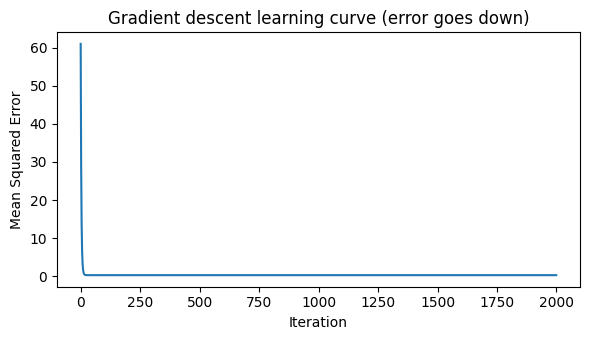

In [7]:
# Watch gradient descent's error shrink toward zero, step by step.
plt.figure(figsize=(6, 3.5))
plt.plot(m_grad.cost_history)
plt.xlabel("Iteration"); plt.ylabel("Mean Squared Error")
plt.title("Gradient descent learning curve (error goes down)")
plt.tight_layout(); plt.show()

## Step 3 — Prepare the features (encode, split, scale)

Three preparation steps every regression needs:
- **Encode** the text column `region` into 0/1 number columns (one-hot).
- **Split** into a training set (to learn) and a test set (to judge honestly).
- **Scale** features to mean 0 / std 1 so coefficients are comparable and
  regularisation is fair. We fit the scaler on **train only** to avoid leakage.

In [8]:
# Our model target is the LOG of the loss (from Step 1's reasoning).
y_log = np.log(df["loss_amount"].to_numpy())

# One-hot encode region. drop_first leaves one region as the baseline.
region_dummies = pd.get_dummies(df[["region"]], drop_first=True)
numeric = ["loan_amount","collateral_value","annual_income","debt_to_income",
           "interest_rate","loan_term_months","borrower_age",
           "num_prior_defaults","monthly_payment"]
# Glue numeric + region columns into one feature table.
X = pd.concat([df[numeric], region_dummies], axis=1).astype(float)
feature_names = X.columns.tolist()

# 25% held out as a test set the model never trains on.
X_tr, X_te, y_tr, y_te = train_test_split(X, y_log, test_size=0.25, random_state=SEED)

# Scale: learn means/std on TRAIN, apply to both (no peeking at test).
scaler = StandardScaler().fit(X_tr)
X_tr_s = scaler.transform(X_tr)
X_te_s = scaler.transform(X_te)
print("Train rows:", X_tr_s.shape[0], " Test rows:", X_te_s.shape[0],
      " Features:", X_tr_s.shape[1])

Train rows: 4500  Test rows: 1500  Features: 12


## Step 4 — Train Linear, Ridge, and Lasso, and compare

All three are linear models; the difference is the **penalty** on big weights:
- **Linear (OLS):** no penalty.
- **Ridge (L2):** shrinks weights smoothly; stabilises correlated features.
- **Lasso (L1):** can push weak weights to *exactly zero* (feature selection).

We score with the right regression metrics, converted back to **dollars**:
- **RMSE** — typical error, punishes big misses (sensitive to outliers).
- **MAE** — average error, more forgiving.
- **MAPE** — average % error (banker-friendly).
- **R²** — fraction of variation explained (1.0 = perfect).

In [9]:
def mape(y_true, y_pred):
    # Mean Absolute Percentage Error: average of |actual-pred|/|actual| as a %.
    return float(np.mean(np.abs((y_true - y_pred)/y_true)) * 100)

models = {"LinearRegression": LinearRegression(),
          "Ridge(alpha=1.0)": Ridge(alpha=1.0),
          "Lasso(alpha=0.01)": Lasso(alpha=0.01, max_iter=10000)}

rows = []
for name, model in models.items():
    model.fit(X_tr_s, y_tr)                      # learn on scaled training data
    pred_log = model.predict(X_te_s)             # predictions are in log space
    pred = np.exp(pred_log); true = np.exp(y_te) # convert back to dollars
    rows.append({"model": name,
                 "RMSE_$": round(float(np.sqrt(mean_squared_error(true, pred)))),
                 "MAE_$":  round(float(mean_absolute_error(true, pred))),
                 "MAPE_%": round(mape(true, pred), 1),
                 "R2":     round(float(r2_score(y_te, pred_log)), 3)})
pd.DataFrame(rows).set_index("model")

,RMSE_$,MAE_$,MAPE_%,R2
model,,,,
LinearRegression,14280,3707,21.7,0.797
Ridge(alpha=1.0),14254,3704,21.7,0.797
Lasso(alpha=0.01),11981,3524,22.1,0.793


### Cross-validation: a steadier performance estimate

One split can be lucky. 5-fold CV trains on 5 different splits and averages —
a more reliable read on true performance.

In [10]:
cv = cross_val_score(LinearRegression(), scaler.transform(X), y_log, cv=5, scoring="r2")
print(f"5-fold CV R2 (Linear): mean={cv.mean():.3f}  std={cv.std():.3f}")

5-fold CV R2 (Linear): mean=0.797  std=0.009


### Does our from-scratch model match scikit-learn?

If it does, we truly understand what scikit-learn is doing under the hood.

In [11]:
scratch = LinearRegressionScratch("normal").fit(X_tr_s, y_tr)
print(f"From-scratch R2: {r2_score(y_te, scratch.predict(X_te_s)):.3f}")
print(f"sklearn Linear R2: {r2_score(y_te, models['LinearRegression'].predict(X_te_s)):.3f}")

From-scratch R2: 0.797
sklearn Linear R2: 0.797


## Step 5 — Diagnostics (the Model Risk part)

A model can score well yet be **wrong for the wrong reasons**. Reviewers check:

- **Residuals vs Fitted:** leftover errors should be a random cloud around 0.
  A funnel shape = *heteroscedasticity* (error grows with size) → bad.
- **Normal QQ plot:** residuals should fall on the diagonal if roughly normal.
- **VIF (multicollinearity):** whether a feature is predictable from the others.
  High VIF (>5, definitely >10) makes coefficients unstable and untrustworthy.
- **Coefficient signs:** do they match business intuition?

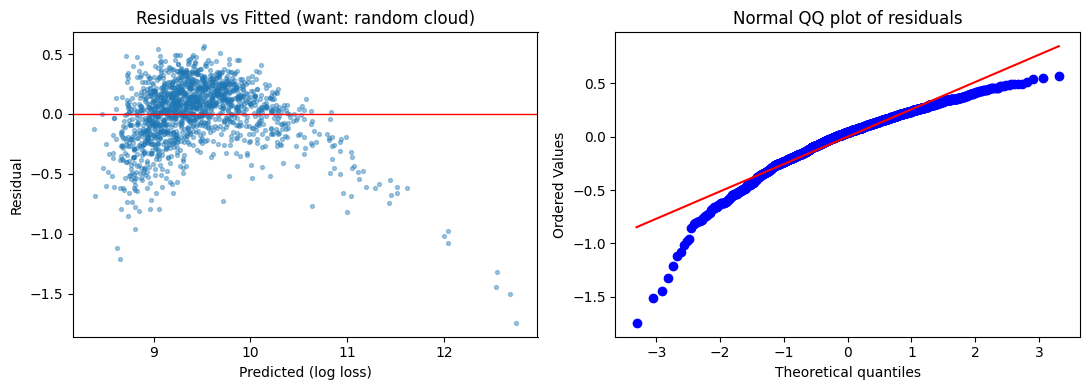

In [12]:
lin = models["LinearRegression"]                 # use the plain model for diagnostics
resid = y_te - lin.predict(X_te_s)               # residual = truth - prediction

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
# Left: residuals vs fitted -> want a shapeless cloud centred on the red line.
ax[0].scatter(lin.predict(X_te_s), resid, s=8, alpha=0.4)
ax[0].axhline(0, color="red", lw=1)
ax[0].set_xlabel("Predicted (log loss)"); ax[0].set_ylabel("Residual")
ax[0].set_title("Residuals vs Fitted (want: random cloud)")
# Right: QQ plot -> points on the line means residuals are roughly normal.
stats.probplot(resid, dist="norm", plot=ax[1])
ax[1].set_title("Normal QQ plot of residuals")
plt.tight_layout(); plt.show()

In [13]:
def compute_vif(X_df):
    # VIF for a feature = 1 / (1 - R^2) when the OTHER features predict it.
    out = []
    for col in X_df.columns:
        y_i = X_df[col].to_numpy()                       # this feature as target
        others = X_df.drop(columns=[col]).to_numpy()     # the rest as inputs
        r2 = LinearRegression().fit(others, y_i).score(others, y_i)
        out.append(1.0/(1.0-r2) if r2 < 0.9999 else np.inf)
    return pd.DataFrame({"feature": X_df.columns, "VIF": np.round(out, 2)}
                        ).sort_values("VIF", ascending=False)

# Note how loan_amount, monthly_payment and collateral_value are correlated.
compute_vif(df[numeric])

,feature,VIF
0,loan_amount,4.71
8,monthly_payment,3.64
1,collateral_value,3.51
5,loan_term_months,2.50
3,debt_to_income,2.13
4,interest_rate,2.13
2,annual_income,1.00
6,borrower_age,1.00
7,num_prior_defaults,1.00


In [14]:
# Coefficients (on scaled features, so the magnitudes are comparable).
# Bigger |weight| = stronger effect. Check the SIGNS make business sense.
coefs = pd.DataFrame({"feature": feature_names, "weight": lin.coef_.round(3)})
coefs.reindex(coefs.weight.abs().sort_values(ascending=False).index).reset_index(drop=True)

,feature,weight
0,loan_amount,0.702
1,collateral_value,-0.289
2,debt_to_income,0.096
3,num_prior_defaults,0.093
4,region_West,0.063
5,region_North,0.062
6,interest_rate,0.058
7,region_East,0.026
8,monthly_payment,0.013
9,loan_term_months,0.012


**Reading the coefficients (and why they're "correct"):** because we built
the data, we know the truth, and the signs should match:

| Feature | Expected sign | Why |
|---|---|---|
| loan_amount | **+** (largest) | bigger loan → bigger dollar loss |
| collateral_value | **−** | more collateral → recover more → less loss |
| debt_to_income | **+** | more debt burden → more loss |
| num_prior_defaults | **+** | repeat defaulters lose more |
| interest_rate | **+** | riskier (pricier) loans lose more |
| annual_income, borrower_age | **≈ 0** | we never built these into the loss |

"Do the coefficient signs agree with intuition?" is the first thing a reviewer asks.

## Interview prep — answer these out loud

**Conceptual**
1. *Why not accuracy for regression?* Accuracy is for classes; regression uses
   error magnitude — RMSE, MAE, MAPE, R².
2. *RMSE vs MAE?* RMSE squares errors, punishing big misses (outlier-sensitive);
   MAE is the plain average. RMSE ≫ MAE signals a few large errors.
3. *What is R²?* Fraction of the target's variance explained; pair it with an
   error metric in real units.
4. *OLS assumptions?* Linearity, independent errors, constant error variance,
   roughly normal residuals, low multicollinearity.
5. *Why log-transform the target?* It's right-skewed and positive; logging makes
   it symmetric. Remember to exponentiate predictions back to dollars.
6. *Ridge vs Lasso?* Ridge keeps and stabilises correlated features; Lasso also
   zeroes weak ones (feature selection).
7. *Normal Equation vs Gradient Descent?* Normal eq is exact but costs a matrix
   inverse (bad for very wide data); gradient descent scales and generalises but
   needs a learning rate and feature scaling.

**Model Risk flavoured**
8. *How would you validate this?* Out-of-sample and out-of-*time* testing, check
   coefficient signs, residual diagnostics, stability over time, benchmark vs a
   simpler model, and document limitations.
9. *Risk of multicollinearity in a regulatory model?* Unstable coefficients →
   unreliable attribution → you can't defend "which factor drove the loss".
10. *Why scale features?* Fair regularisation, faster gradient-descent
    convergence, comparable coefficient magnitudes.

## Limitations (say these unprompted — reviewers value honesty)
- Synthetic data — do **not** draw real conclusions; swap in real data.
- LGD is bounded [0,1]; we modelled logged dollars. A stricter approach is
  *beta regression* or a fractional-response model — a strong "what next" answer.
- Headline numbers used one split; CV and out-of-*time* testing matter more in banking.

---
**Next module:** `02_classification` — Probability of Default (the "PD"), where we
build logistic regression from scratch and learn precision/recall, ROC/PR curves,
and threshold choice.